In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import confusion_matrix

## Registri Data

In [3]:
reports_dir = os.path.join('..', 'reports')
evaluation_file = os.path.join(reports_dir, 'all_models_evaluation.csv')

df_results = pd.read_csv(evaluation_file)

# Set Visualisasi

In [ ]:
sns.set_theme(style="whitegrid")

## Visualisasi Perbandingan Akurasi

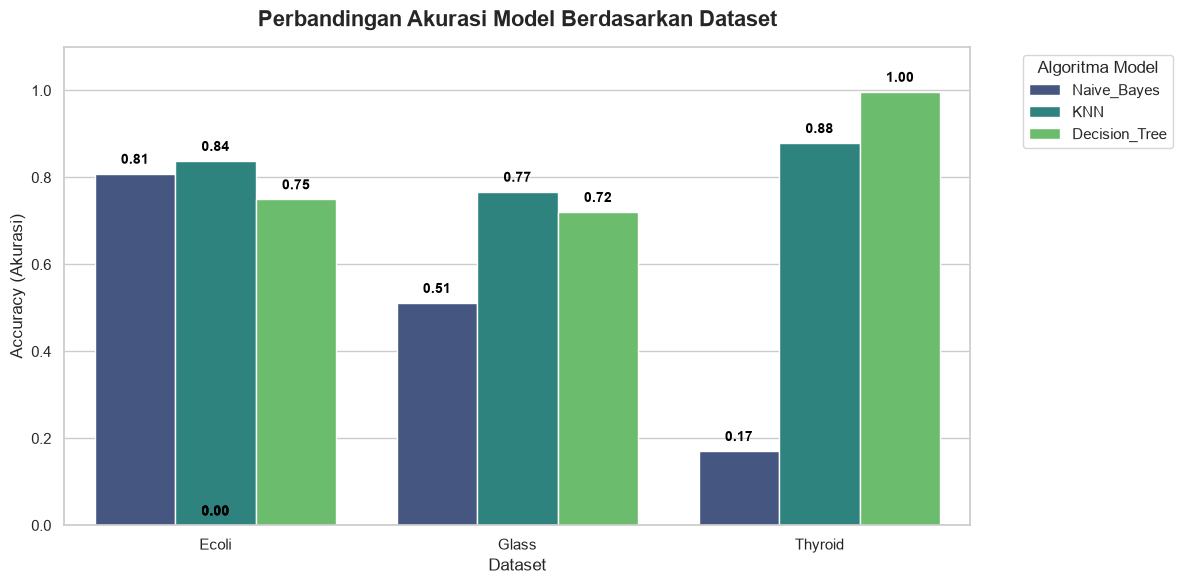

[2] Grafik perbandingan akurasi berhasil dibuat dan disimpan.


In [ ]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(data=df_results, x='Dataset', y='Accuracy', hue='Model', palette='viridis')

plt.title('Perbandingan Akurasi Model Berdasarkan Dataset', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Dataset', fontsize=12)
plt.ylabel('Accuracy (Akurasi)', fontsize=12)
plt.ylim(0, 1.1)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.legend(title='Algoritma Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig(os.path.join(reports_dir, 'accuracy_comparison_chart.png'), dpi=300)
plt.show()

print("[2] Grafik perbandingan akurasi berhasil dibuat dan disimpan.")

## Automasi Visualisasi Confusion Matriks

In [ ]:
def plot_best_confusion_matrix(dataset_name, best_model_name):
    data_dir = os.path.join('..', 'dataset', 'engineered')
    models_dir = os.path.join('..', 'models')
    
    test_path = os.path.join(data_dir, f"{dataset_name.lower()}_test_engineered.csv")
    model_path = os.path.join(models_dir, f"{dataset_name.lower()}_{best_model_name.lower()}.pkl")
    
    df_test = pd.read_csv(test_path)
    X_test = df_test.drop(columns=['label_encoded'])
    y_true = df_test['label_encoded']
    
    model = joblib.load(model_path)
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix: {dataset_name.capitalize()}\n(Best Model: {best_model_name.replace("_", " ")})', 
              fontsize=14, fontweight='bold', pad=10)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    
    plt.savefig(os.path.join(reports_dir, f'cm_{dataset_name.lower()}_{best_model_name.lower()}.png'), dpi=300)
    plt.show()

print("[3] Fungsi Confusion Matrix siap digunakan.")

[3] Fungsi Confusion Matrix siap digunakan.


## Hasil CM `ecoli` model

--- ECOLI (Best Model: KNN) ---


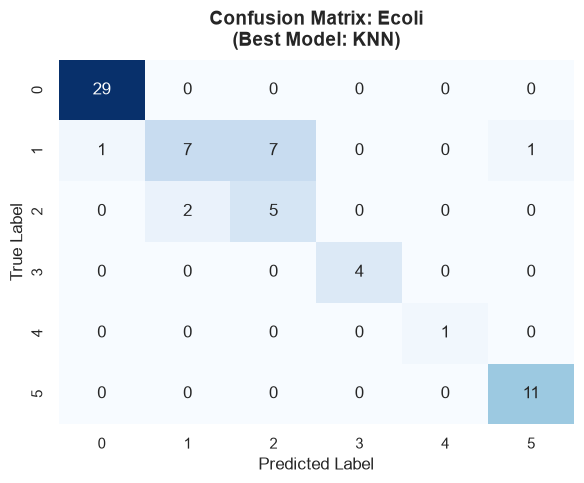

In [8]:
print("--- ECOLI (Best Model: KNN) ---")
plot_best_confusion_matrix('ecoli', 'KNN')

## Hasil CM `glass` model

--- GLASS (Best Model: KNN) ---


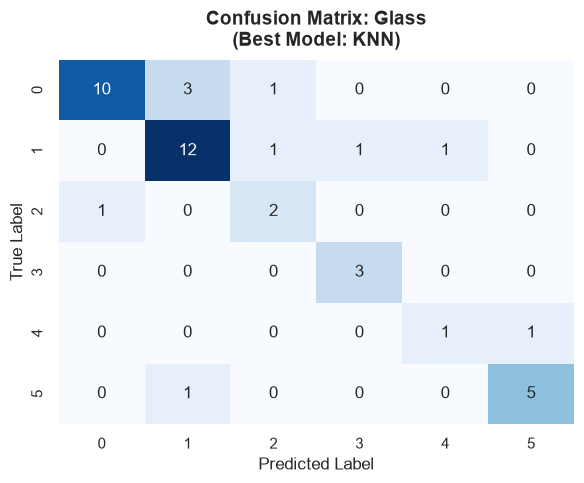

In [9]:
print("--- GLASS (Best Model: KNN) ---")
plot_best_confusion_matrix('glass', 'KNN')


## Hasil CM `thyroid` model

--- THYROID (Best Model: Decision Tree) ---


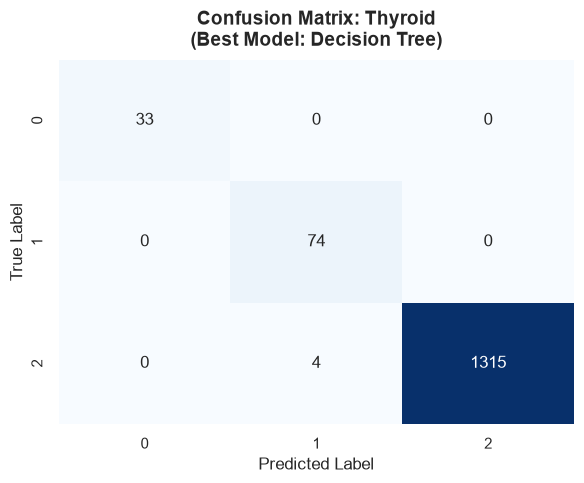

In [10]:
print("--- THYROID (Best Model: Decision Tree) ---")
plot_best_confusion_matrix('thyroid', 'Decision_Tree')

# Kesimpulan

Berdasarkan serangkaian eksperimen (*Data Cleansing, Feature Scaling, Hybrid Resampling*, dan *Model Training*), dapat ditarik kesimpulan sebagai berikut:

1. **Dataset ECOLI (Akurasi Tertinggi: KNN - 83.82%)**
   KNN unggul dalam dataset ini. Fitur-fitur probabilitas kontinu pada Ecoli sangat cocok dihitung menggunakan metrik jarak (Euclidean) milik KNN, terutama setelah nilai fitur diseimbangkan (*Feature Scaling*).
2. **Dataset GLASS (Akurasi Tertinggi: KNN - 76.74%)**
   KNN kembali menjadi model terbaik. Hal ini menegaskan bahwa proporsi kandungan kimia kaca sangat mengandalkan kedekatan spasial antar-komponen. Naïve Bayes memiliki performa terburuk di sini karena fitur kimia tidak bersifat independen satu sama lain.
3. **Dataset THYROID (Akurasi Tertinggi: Decision Tree - 99.72%)**
   Pada data berskala besar (7.200 baris) dengan banyak atribut biner/kategorikal seperti dataset medis Thyroid, model berbasis pohon (Decision Tree) menunjukkan keagresifannya yang luar biasa. Kemampuannya membuat aturan *If-Else* sukses memetakan gejala penyakit secara nyaris sempurna.

**Saran Pengembangan Lanjutan:**
* Untuk dataset Glass dan Ecoli yang memiliki sampel sangat sedikit, dapat dicoba teknik validasi silang (*K-Fold Cross Validation*) untuk memastikan tidak terjadi bias pada pembagian data train-test.
* Melakukan *Hyperparameter Tuning* (misal: mencari nilai `K` optimal untuk KNN dengan *GridSearchCV*).